In [3]:
############CHARGEMENT DU CSV ET TABLEAU DE DESCRIPTION DES COLONNES########

# Chargement du CSV et vue des 5 premières lignes
import pandas as pd
df = pd.read_csv("../data/thelook_fr_women_2023_2024.csv")
# Nous allons préserver les données brutes et travailler en toute sécurité sur une version modifiable, une copie.
df_copie = df.copy().round(2)
df_copie.head()

,order_id,order_item_id,product_id,item_created_at,item_status,sale_price,cost,category,department,brand,product_name,order_status,order_created_at,shipped_at,delivered_at,user_id,gender,country,state,city
0,19425,28112,6983,2023-01-01 06:18:03+00:00,Shipped,29.50,16.05,Shorts,Women,Fox,Fox Juniors Momentum Short,Shipped,2022-12-29 10:00:00+00:00,2022-12-30 11:29:00+00:00,NaN,15644,F,France,Centre-Val de Loire,Corquilleroy
1,19425,28113,10597,2023-01-01 06:44:58+00:00,Shipped,20.00,10.00,Intimates,Women,Wacoal,Wacoal Women's B-Smooth Bralette,Shipped,2022-12-29 10:00:00+00:00,2022-12-30 11:29:00+00:00,NaN,15644,F,France,Centre-Val de Loire,Corquilleroy
2,4710,6730,11792,2023-01-03 04:44:50+00:00,Complete,38.00,18.47,Intimates,Women,American Apparel,American Apparel Striped Chiffon Tank,Complete,2023-01-03 08:12:00+00:00,2023-01-03 09:14:00+00:00,2023-01-04 03:03:00+00:00,3853,F,France,Île-de-France,Paris
3,16618,24006,329,2023-01-03 15:13:39+00:00,Complete,27.99,16.40,Tops & Tees,Women,Tri-Mountain,Tri-Mountain Women's 3/4-Sleeve Pique Knit Pol...,Complete,2023-01-03 18:58:00+00:00,2023-01-05 13:23:00+00:00,2023-01-09 10:25:00+00:00,13422,F,France,Hauts-de-France,Comines
4,4710,6731,5295,2023-01-05 06:43:09+00:00,Complete,56.88,29.58,Pants & Capris,Women,Lauren by Ralph Lauren,Lauren Ralph Lauren Velour Pants,Complete,2023-01-03 08:12:00+00:00,2023-01-03 09:14:00+00:00,2023-01-04 03:03:00+00:00,3853,F,France,Île-de-France,Paris


In [4]:
import sys
from pathlib import Path
sys.path.append(str(Path("../src").resolve()))
from utils import exemple_valeurs_dataset,valeurs_manquantes_shipped_at_par_statut,valeurs_manquantes_delivered_at_par_statut
# Définitions des colonnes
definitions: list[str] = [
    "Identifiant unique de la commande. Une commande peut contenir plusieurs produits.",
    "Identifiant unique d'une ligne de commande (un produit dans une commande). Chaque produit commandé possède son propre identifiant.",
    "Identifiant unique du produit vendu. Permet de relier les ventes aux informations du produit.",
    "Date et heure de création de la ligne de commande (ajout du produit à la commande).",
    "État de la ligne de commande (par exemple : Shipped,Complete,Processing,Returned,Cancelled).",
    "Prix de vente du produit payé par le client.",
    "Coût d'achat ou de revient du produit pour l'entreprise. Sert au calcul de la marge_par_mois_2023_2024.",
    "Catégorie commerciale du produit (ex. : Jeans, Shorts, Accessories).",
    "Département ou grande famille de produits (ex. : Women).",
    "Marque du produit. Certaines valeurs peuvent être manquantes.",
    "Nom descriptif du produit.",
    "Statut global de la commande (Shipped,Complete,Processing,Returned,Cancelled). Contrairement à item_status, il concerne la commande entière.",
    "Date et heure de création de la commande.",
    "Date et heure d'expédition de la commande. Les valeurs manquantes indiquent généralement que la commande n'a pas encore été expédiée ou a été annulée.",
    "Date et heure de livraison au client. Les valeurs manquantes peuvent signifier que la commande est encore en cours de livraison, annulée ou retournée.",
    "Identifiant unique du client ayant passé la commande.",
    "Sexe du client (Male/Female).",
    "Pays de résidence du client.",
    "État, province ou région du client.",
    "Ville de résidence du client."
]

# Types de variables
types_variables: list[str] = [
    "Identifiant",
    "Identifiant",
    "Identifiant",
    "Date/Heure",
    "Variable catégorielle",
    "Variable numérique",
    "Variable numérique",
    "Variable catégorielle",
    "Variable catégorielle",
    "Variable catégorielle",
    "Texte",
    "Variable catégorielle",
    "Date/Heure",
    "Date/Heure",
    "Date/Heure",
    "Identifiant",
    "Variable catégorielle",
    "Variable catégorielle",
    "Variable catégorielle",
    "Variable catégorielle"
]

# Création du tableau descriptif des colonnes du dataset.
description_colonnes_dataset_df = pd.DataFrame({
    "colonne": df_copie.columns,
    "définition": definitions,
    "type de variable": types_variables,
    "type de donnée": df_copie.dtypes.astype(str).values,
    "exemple": exemple_valeurs_dataset(df_copie)
})
# Ligne pour éviter de tronquer les colonnes de texte dans l'affichage du DataFrame
pd.set_option("display.max_colwidth", None)
# Affichage
description_colonnes_dataset_df

,colonne,définition,type de variable,type de donnée,exemple
0,order_id,Identifiant unique de la commande. Une commande peut contenir plusieurs produits.,Identifiant,int64,19425
1,order_item_id,Identifiant unique d'une ligne de commande (un produit dans une commande). Chaque produit commandé possède son propre identifiant.,Identifiant,int64,28112
2,product_id,Identifiant unique du produit vendu. Permet de relier les ventes aux informations du produit.,Identifiant,int64,6983
3,item_created_at,Date et heure de création de la ligne de commande (ajout du produit à la commande).,Date/Heure,str,2023-01-01 06:18:03+00:00
4,item_status,"État de la ligne de commande (par exemple : Shipped,Complete,Processing,Returned,Cancelled).",Variable catégorielle,str,Shipped
5,sale_price,Prix de vente du produit payé par le client.,Variable numérique,float64,29.5
6,cost,Coût d'achat ou de revient du produit pour l'entreprise. Sert au calcul de la marge_par_mois_2023_2024.,Variable numérique,float64,16.05
7,category,"Catégorie commerciale du produit (ex. : Jeans, Shorts, Accessories).",Variable catégorielle,str,Shorts
8,department,Département ou grande famille de produits (ex. : Women).,Variable catégorielle,str,Women
9,brand,Marque du produit. Certaines valeurs peuvent être manquantes.,Variable catégorielle,str,Fox


In [5]:
# Définition des statuts utilisés pour order_status et item_status

#Statuts
statuts: list[str] = [
    "Shipped",
    "Complete",
    "Processing",
    "Returned",
    "Cancelled"
]
# Définition des statuts
descriptions_statuts: list[str] = [
    "La commande a été expédiée par le vendeur et est en cours d'acheminement vers le client. Elle n'a pas encore été livrée.",
    "La commande a été livrée avec succès et le processus de vente est terminé. C'est généralement une vente finalisée.",
    "La commande est en cours de traitement (préparation, vérification du paiement, emballage, etc.) mais n'a pas encore été expédiée.",
    "La commande a été retournée par le client après la livraison. Selon les règles du vendeur, elle peut donner lieu à un remboursement ou à un échange.",
    "La commande a été annulée avant d'être finalisée. Elle n'a généralement pas été expédiée. L'annulation peut venir du client, du vendeur ou être due à un problème de paiement ou de stock."
]
# Dataframe du descriptif des statuts 
df_descriptions_statuts = pd.DataFrame({
    "statut de commande": statuts,
    "description du statut": descriptions_statuts
})

# Affichage du tableau descriptif des statuts 
df_descriptions_statuts

,statut de commande,description du statut
0,Shipped,La commande a été expédiée par le vendeur et est en cours d'acheminement vers le client. Elle n'a pas encore été livrée.
1,Complete,La commande a été livrée avec succès et le processus de vente est terminé. C'est généralement une vente finalisée.
2,Processing,"La commande est en cours de traitement (préparation, vérification du paiement, emballage, etc.) mais n'a pas encore été expédiée."
3,Returned,"La commande a été retournée par le client après la livraison. Selon les règles du vendeur, elle peut donner lieu à un remboursement ou à un échange."
4,Cancelled,"La commande a été annulée avant d'être finalisée. Elle n'a généralement pas été expédiée. L'annulation peut venir du client, du vendeur ou être due à un problème de paiement ou de stock."


In [6]:
# Nous évoluerons sur les hypothèses suivantes:

# Schéma simplifié de vie d'une ligne de commande : order_created -> processing -> shipped -> complete -> returned (si le client renvoie)

# À tout moment "avant la livraison", la commande peut également devenir "cancelled" (annulée) si le client annule sa commande ou si le vendeur décide de l'annuler.

# Returned : vente annulée après livraison ; nous considérons que les commandes retournées donnent lieu à un échange (pas un remboursement) avec le produit de même valeur.


In [7]:
# dimensions du DataFrame 
print(df_copie.shape)
# Informations générales sur le DataFrame
print(df_copie.info())

(1679, 20)
<class 'pandas.DataFrame'>
RangeIndex: 1679 entries, 0 to 1678
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          1679 non-null   int64  
 1   order_item_id     1679 non-null   int64  
 2   product_id        1679 non-null   int64  
 3   item_created_at   1679 non-null   str    
 4   item_status       1679 non-null   str    
 5   sale_price        1679 non-null   float64
 6   cost              1679 non-null   float64
 7   category          1679 non-null   str    
 8   department        1679 non-null   str    
 9   brand             1677 non-null   str    
 10  product_name      1679 non-null   str    
 11  order_status      1679 non-null   str    
 12  order_created_at  1679 non-null   str    
 13  shipped_at        1133 non-null   str    
 14  delivered_at      636 non-null    str    
 15  user_id           1679 non-null   int64  
 16  gender            1679 non-null   str    


In [8]:
###############################CONTROLE DE QUALITE#####################
# Valeurs manquantes par colonne
df_copie.isnull().sum()

order_id               0
order_item_id          0
product_id             0
item_created_at        0
item_status            0
sale_price             0
cost                   0
category               0
department             0
brand                  2
product_name           0
order_status           0
order_created_at       0
shipped_at           546
delivered_at        1043
user_id                0
gender                 0
country                0
state                  0
city                   0
dtype: int64

In [9]:
# La colonne brand  est une variable catégorielle qui a 2 valeurs manquantes; nous ne pouvons pas les remplacer par une modalité car la modalité la plus fréquente a un taux de présence 6% (qui est <50%); calcul fait avec : df["brand"].value_counts(normalize=True)*100. Aussi, nous ne devons pas supprimer les lignes/colonnes correspondantes au risque de perdre des informations. Nous choisissons de les imputer par "unknown".
df_copie["brand"]=df_copie['brand'].fillna("unknown") 

In [10]:
# La colonne shipped_at indique la date d'expédition. Une valeur manquante signifie souvent que la commande est: soit encore en cours de traitement (Processing) ou a été annulée (Cancelled) ; 
# Regardons de plus près avec les statuts (order_status) correspondants à ces valeurs manquantes.
valeurs_manquantes_shipped_at_par_statut(df_copie)
# Le tableau ci-dessous montre que les valeurs manquantes de shipped_at sont principalement associées aux statuts Processing(306) et Cancelled(240); et on a 546=306+240. Cela confirme que les commandes avec des valeurs manquantes dans shipped_at sont soit en cours de traitement, soit annulées. Il est donc logique de conserver ces valeurs manquantes; car elles reflètent l'état réel des commandes. Pour les autres statuts, il n'y a pas de valeurs manquantes, ce qui indique que les commandes ont été expédiées ou livrées avec succès.

,Order_Status,Nbre_valeurs_manquantes_shipped_at
0,Processing,306
1,Shipped,0
2,Completed,0
3,Cancelled,240
4,Returned,0
5,Statut Manquant,0


In [11]:
# La colonne delivered_at indique la date de livraison. Une valeur manquante signifie généralement que la commande n'a pas encore été livrée : elle est soit encore en cours de traitement (Processing), soit en cours d'acheminement (Shipped), soit elle a été annulée (Cancelled)
# Regardons de plus près avec les statuts (order_status) correspondants à ces valeurs manquantes. 
valeurs_manquantes_delivered_at_par_statut(df_copie)
# Le tableau ci-dessous montre que les valeurs manquantes de delivered_at sont principalement associées aux statuts Processing(306),Shipped(497) et Cancelled(240); et on a 1043=306+497+240. Cela confirme que les commandes avec des valeurs manquantes dans delivered_at sont soit en cours de traitement (Processing), soit en cours d'acheminement (Shipped), soit  annulées (Cancelled). Il est donc logique de conserver ces valeurs manquantes; car elles reflètent l'état réel des commandes. Pour les autres statuts, il n'y a pas de valeurs manquantes, ce qui indique que les commandes ont été expédiées ou livrées avec succès.

,Order_Status,Nbre_valeurs_manquantes_delivered_at
0,Processing,306
1,Shipped,497
2,Completed,0
3,Cancelled,240
4,Returned,0
5,Statut Manquant,0


In [12]:
# Doublons
df_copie.duplicated().sum()
# L'analyse des doublons à l'aide de df_copie.duplicated().sum() montre qu'aucune ligne n'est dupliquée (0 doublon). Aucun traitement de suppression des doublons n'est donc nécessaire

np.int64(0)

In [13]:
# Formats de Dates:
# Nous avons 4 variables date/heure : order_created_at, shipped_at, delivered_at et item_created_at. Nous allons vérifier si elles sont bien au format datetime.
df_copie[["item_created_at","order_created_at","shipped_at","delivered_at"]].dtypes

item_created_at     str
order_created_at    str
shipped_at          str
delivered_at        str
dtype: object

In [14]:
# Le résultat montre que ces colonnes sont actuellement de type object (chaîne de caractères). Pour effectuer des analyses temporelles, il est nécessaire de les convertir en type datetime. Nous allons donc procéder à cette conversion.
colonnes_date = ["item_created_at","order_created_at","shipped_at","delivered_at"]
for i in colonnes_date:
  df_copie[i]=pd.to_datetime(df_copie[i])
  print(f"Le nouveau type de la colonne {i} est {df_copie[i].dtype}")

Le nouveau type de la colonne item_created_at est datetime64[us, UTC]
Le nouveau type de la colonne order_created_at est datetime64[us, UTC]
Le nouveau type de la colonne shipped_at est datetime64[us, UTC]
Le nouveau type de la colonne delivered_at est datetime64[us, UTC]


In [15]:
# Après conversion, vérifions maintenant les cohérences des dates

# Donnons la liste d'années présentes dans les colonnes de dates pour vérifier si elles se situent bien dans le périmètre 2023 - 2024.
from datetime import datetime
print(df_copie["item_created_at"].dt.year.value_counts())
print(df_copie["order_created_at"].dt.year.value_counts())
print(df_copie["shipped_at"].dt.year.value_counts())
print(df_copie["delivered_at"].dt.year.value_counts())

item_created_at
2024    968
2023    711
Name: count, dtype: int64
order_created_at
2024    968
2023    709
2022      2
Name: count, dtype: int64
shipped_at
2024.0    670
2023.0    459
2022.0      2
2025.0      2
Name: count, dtype: int64
delivered_at
2024.0    400
2023.0    234
2025.0      2
Name: count, dtype: int64


In [16]:
# Nous notons que certaines dates sont de 2022 , 2025, NaN. 

# Nous avons dejà étudié les valeurs manquantes (NaN) dans les colonnes shipped_at et delivered_at. 
# Pour les années 2022 et 2025, il est important de vérifier si elles sont cohérentes avec le contexte de l'analyse. Si ces dates sont des erreurs ou des anomalies, nous devrons décider comment les traiter (par exemple, les corriger, les supprimer ou les conserver en fonction de leur impact sur l'analyse).
# Ressortons les "lignes" (correspondantes aux variables date uniquement) qui ont des "dates en 2022 et/ou 2025" pour les examiner de plus près.
df_copie[(df_copie["order_created_at"].dt.year==2022) | (df_copie["shipped_at"].dt.year==2022) | (df_copie["shipped_at"].dt.year==2025) | (df_copie["delivered_at"].dt.year==2025)][["item_created_at","order_created_at","shipped_at","delivered_at"]]


,item_created_at,order_created_at,shipped_at,delivered_at
0,2023-01-01 06:18:03+00:00,2022-12-29 10:00:00+00:00,2022-12-30 11:29:00+00:00,NaT
1,2023-01-01 06:44:58+00:00,2022-12-29 10:00:00+00:00,2022-12-30 11:29:00+00:00,NaT
1661,2024-12-27 04:27:59+00:00,2024-12-27 05:27:00+00:00,2024-12-28 21:46:00+00:00,2025-01-02 00:39:00+00:00
1674,2024-12-31 02:04:52+00:00,2024-12-31 03:27:00+00:00,2025-01-01 08:59:00+00:00,2025-01-02 13:06:00+00:00
1675,2024-12-31 04:28:58+00:00,2024-12-31 05:13:00+00:00,2025-01-02 02:26:00+00:00,NaT


In [17]:
# Les lignes 1661 , 1674 et 1675 sont des cas normaux:
# 1661: Commande créée fin 2024, expédiée le 28/12/2024, livrée le 02/01/2025.
# 1674: Commande créée le 31/12/2024, expédiée le 01/01/2025, livrée le 02/01/2025.
# 1675: Commande créée le 31/12/2024, expédiée le 02/01/2025, pas encore livrée (NaT).
# Je trouve les lignes 1661 , 1674, et 1675 comme des cas normaux.

In [18]:
# Les lignes 0 et 1:  item_created_at est en 2023, alors que order_created_at et shipped_at sont en 2022. il est curieux qu'un article soit créé après que la commande ait déjà été expédiée.

# Regardons de manière globale s'il n'y a pas des cas similaires:
# Pour se faire,nous allons vérifier si les dates d'expédition (shipped_at) et de livraison (delivered_at) sont postérieures à la date de création de la commande/item (order_created_at/item_created_at). De plus, nous allons aussi vérifier que la date de livraison est postérieure à la date d'expédition. 

# Vérifications si les dates shipped_at sont postérieures aux dates correspondantes item_created_at/order_created
masque_coherence_item_order_and_shipped=(df_copie["item_created_at"]>df_copie["shipped_at"])|(df_copie["order_created_at"]>df_copie["shipped_at"])
masque_coherence_item_order_and_shipped.sum()
# L'output suivant nous montre qu'il y'a plusieurs cas incohérents (365).




np.int64(375)

In [19]:
# L'output suivant nous montre que certaines de ces lignes présentent à la fois order_status et item_status à completed. Je pense donc qu'il ne faut pas les supprimer, puisqu'elles correspondent(certaines) à des commandes effectivement finalisées et approuvées par les clients. Concernant les lignes dont le statut n'est pas completed, je propose de les conserver également pour le moment ; nous reviendrons sur leur interprétation lors de l'analyse du comportement des clients.
df_copie[masque_coherence_item_order_and_shipped]

,order_id,order_item_id,product_id,item_created_at,item_status,sale_price,cost,category,department,brand,product_name,order_status,order_created_at,shipped_at,delivered_at,user_id,gender,country,state,city
0,19425,28112,6983,2023-01-01 06:18:03+00:00,Shipped,29.50,16.05,Shorts,Women,Fox,Fox Juniors Momentum Short,Shipped,2022-12-29 10:00:00+00:00,2022-12-30 11:29:00+00:00,NaT,15644,F,France,Centre-Val de Loire,Corquilleroy
1,19425,28113,10597,2023-01-01 06:44:58+00:00,Shipped,20.00,10.00,Intimates,Women,Wacoal,Wacoal Women's B-Smooth Bralette,Shipped,2022-12-29 10:00:00+00:00,2022-12-30 11:29:00+00:00,NaT,15644,F,France,Centre-Val de Loire,Corquilleroy
4,4710,6731,5295,2023-01-05 06:43:09+00:00,Complete,56.88,29.58,Pants & Capris,Women,Lauren by Ralph Lauren,Lauren Ralph Lauren Velour Pants,Complete,2023-01-03 08:12:00+00:00,2023-01-03 09:14:00+00:00,2023-01-04 03:03:00+00:00,3853,F,France,Île-de-France,Paris
15,3676,5250,2506,2023-01-16 10:37:00+00:00,Complete,15.99,6.54,Active,Women,SmartWool,Smartwool Women's Snow Swirl Sock,Complete,2023-01-15 12:38:00+00:00,2023-01-15 12:47:00+00:00,2023-01-20 07:21:00+00:00,3025,F,France,Nouvelle-Aquitaine,Saintes
16,117152,170201,6460,2023-01-16 11:01:44+00:00,Shipped,25.00,12.03,Shorts,Women,Sam & Lavi,Sam & Lavi Women's Addison Lace Short,Shipped,2023-01-14 11:28:00+00:00,2023-01-16 08:38:00+00:00,NaT,93675,F,France,Auvergne-Rhône-Alpes,Rillieux-la-Pape
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1657,64764,94070,15007,2024-12-26 08:49:19+00:00,Complete,59.00,27.79,Maternity,Women,Prego,Prego Maternity Swimsuit Tropic Night Twisted Bandeau,Complete,2024-12-22 11:15:00+00:00,2024-12-24 02:28:00+00:00,2024-12-24 08:16:00+00:00,51821,F,France,Auvergne-Rhône-Alpes,Roche
1664,54999,79998,12067,2024-12-27 12:56:45+00:00,Complete,30.95,15.13,Intimates,Women,Vx Intimate Inc,Charmuese Chemise or Slip - Women's,Complete,2024-12-23 15:56:00+00:00,2024-12-25 06:32:00+00:00,2024-12-26 14:52:00+00:00,44066,F,France,Auvergne-Rhône-Alpes,Romans-sur-Isère
1672,20700,29947,5709,2024-12-30 12:07:40+00:00,Returned,25.00,14.73,Leggings,Women,Steve Madden,Steve Madden Legwear Womens Basic Leggings,Returned,2024-12-29 14:25:00+00:00,2024-12-30 00:05:00+00:00,2024-12-31 22:07:00+00:00,16691,F,France,Bretagne,Brest
1673,20700,29945,13300,2024-12-30 13:48:36+00:00,Returned,25.00,10.18,Swim,Women,Ritchie Swimwear,Ritchie Swimwear White Triangle Bikini Top,Returned,2024-12-29 14:25:00+00:00,2024-12-30 00:05:00+00:00,2024-12-31 22:07:00+00:00,16691,F,France,Bretagne,Brest


In [20]:
# Vérifications si les dates delivered_at sont postérieures aux dates correspondantes item_created_at/order_created
masque_coherence_item_order_and_delivered=(df_copie["item_created_at"]>df_copie["delivered_at"])|(df_copie["order_created_at"]>df_copie["delivered_at"])
masque_coherence_item_order_and_delivered.sum()

np.int64(63)

In [21]:
# L'output suivant nous montre que certaines de ces lignes présentent à la fois order_status et item_status à completed. Je pense donc qu'il ne faut pas les supprimer, puisqu'elles correspondent(certaines) à des commandes effectivement finalisées et approuvées par les clients. Concernant les lignes dont le statut n'est pas completed, je propose de les conserver également pour le moment ; nous reviendrons sur leur interprétation lors de l'analyse du comportement des clients.
df_copie[masque_coherence_item_order_and_delivered]

,order_id,order_item_id,product_id,item_created_at,item_status,sale_price,cost,category,department,brand,product_name,order_status,order_created_at,shipped_at,delivered_at,user_id,gender,country,state,city
4,4710,6731,5295,2023-01-05 06:43:09+00:00,Complete,56.88,29.58,Pants & Capris,Women,Lauren by Ralph Lauren,Lauren Ralph Lauren Velour Pants,Complete,2023-01-03 08:12:00+00:00,2023-01-03 09:14:00+00:00,2023-01-04 03:03:00+00:00,3853,F,France,Île-de-France,Paris
76,57042,82944,7648,2023-02-17 16:10:39+00:00,Returned,26.69,10.25,Blazers & Jackets,Women,Allegra K,Allegra K Ladies Peaked Lapel Single Breasted Autumn Blazer Coat Army Green S,Returned,2023-02-13 18:03:00+00:00,2023-02-15 09:29:00+00:00,2023-02-15 21:15:00+00:00,45672,F,France,Île-de-France,Chevilly-Larue
141,112668,163595,12330,2023-03-28 23:33:50+00:00,Complete,24.00,12.77,Intimates,Women,SEX NIGHT,Flattering Lace Garter Belt Babydoll-Black,Complete,2023-03-26 03:23:00+00:00,2023-03-27 04:05:00+00:00,2023-03-27 08:26:00+00:00,90099,F,France,Île-de-France,Paris
142,112668,163596,10775,2023-03-29 01:34:29+00:00,Complete,15.28,7.81,Intimates,Women,Hanes,Hanes Women's Cotton String Bikini Assorted,Complete,2023-03-26 03:23:00+00:00,2023-03-27 04:05:00+00:00,2023-03-27 08:26:00+00:00,90099,F,France,Île-de-France,Paris
171,92628,134611,8981,2023-04-08 16:18:50+00:00,Complete,12.80,4.63,Socks & Hosiery,Women,K. Bell,Tubular Owl and Stars Non-Skid Slipper Socks by K. Bell,Complete,2023-04-05 16:53:00+00:00,2023-04-06 20:16:00+00:00,2023-04-07 04:06:00+00:00,73940,F,France,Occitanie,Bellefont-La Rauze
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1535,113140,164309,5178,2024-11-20 10:56:46+00:00,Complete,88.00,48.49,Pants & Capris,Women,Hard Tail,Hard Tail Slub Jersey Double Layered Roll Down Pant,Complete,2024-11-17 14:12:00+00:00,2024-11-17 14:45:00+00:00,2024-11-17 15:29:00+00:00,90485,F,France,Pays de la Loire,Angers
1562,123728,179705,12541,2024-11-24 16:39:35+00:00,Complete,11.95,6.46,Intimates,Women,BOOB-EEZ,Boob-eez Headlight Concealer 100% Silicone One Size 6cm,Complete,2024-11-20 18:57:00+00:00,2024-11-21 22:17:00+00:00,2024-11-23 01:53:00+00:00,98875,F,France,Occitanie,Nîmes
1652,41643,60468,12310,2024-12-24 10:32:17+00:00,Complete,23.00,12.37,Intimates,Women,SEX NIGHT,Lace Transparent Babydoll Set-Black,Complete,2024-12-21 14:17:00+00:00,2024-12-23 00:40:00+00:00,2024-12-23 01:04:00+00:00,33444,F,France,Nouvelle-Aquitaine,Benon
1657,64764,94070,15007,2024-12-26 08:49:19+00:00,Complete,59.00,27.79,Maternity,Women,Prego,Prego Maternity Swimsuit Tropic Night Twisted Bandeau,Complete,2024-12-22 11:15:00+00:00,2024-12-24 02:28:00+00:00,2024-12-24 08:16:00+00:00,51821,F,France,Auvergne-Rhône-Alpes,Roche


In [22]:
# Vérifions maintenant que la date de livraison est postérieure à la date d'expédition.
masque_coherence_shipped_and_delivered = df_copie["shipped_at"] > df_copie["delivered_at"]
print(masque_coherence_shipped_and_delivered.sum())

0


In [23]:
# En ce qui concerne la cohérence temporelle, il est important d'attirer l'attention sur les faits suivants :
# 2022 : 02 commandes crées et 02 expéditions faites.
# 2025 : 02 expéditions et 02 livraisons faites.
# En ce qui concerne les incohérences :
# 365 créations de lignes de commande (ajouts de produits aux commandes) pour des commandes dejà expédiées. Mais puisque certaines de ces commandes ont été finalisées et approuvées par des clients (malgré le non alignement entre item_created_at/ordered_at et shipped_at), nous nous proposons donc de conserver toutes ces lignes.
# 63 créations de lignes de commande (ajouts de produits aux commandes) pour des commandes dejà livrées. Mais puisque certaines de ces commandes ont été finalisées et approuvées par des clients (malgré le non alignement entre item_created_at/ordered_at et delivred_at), nous nous proposons donc de conserver toutes ces lignes.

In [24]:
# Regardons les statuts et leurs fréquences pour les colonnes order_status et item_status
print(df_copie["item_status"].value_counts(normalize=True)*100)

item_status
Shipped       29.600953
Complete      25.312686
Processing    18.225134
Cancelled     14.294223
Returned      12.567004
Name: proportion, dtype: float64


In [ ]:
# La répartition suivante des statuts des articles montre que 29,6 % des articles sont expédiés (Shipped), ce qui en fait le statut le plus représenté. Les articles complétés (Complete) représentent 25,3 % des observations, indiquant qu'environ un quart des articles ont été livrés et finalisés. Par ailleurs, 18,2 % des articles sont encore en cours de traitement (Processing). 
# Enfin, les statuts Cancelled (14,3 %) et Returned (12,6 %) représentent ensemble près de 27 % des articles, ce qui traduit une proportion non négligeable d'articles n'ayant pas abouti à une vente définitive.
# Il serait donc important de nous pencher sur les catégories, marques et villes qui ont les plus grands taux d'annulation et de retour de commande.
# Ceci sera intégré dans la section suivante, explorations descriptives.

##########################EXPLORATIONS DESCRIPTIVES#####################3

# Categories, taux d'annulation
pd.crosstab(
    df_copie["category"],
    df_copie["item_status"],
    normalize="index"
).mul(100).round(2).sort_values(by="Cancelled",ascending=False).head(15)


item_status,Cancelled,Complete,Processing,Returned,Shipped
category,,,,,
Leggings,24.53,32.08,15.09,15.09,13.21
Suits,22.22,11.11,16.67,16.67,33.33
Jeans,21.59,20.45,19.32,7.95,30.68
Outerwear & Coats,20.00,23.33,13.33,18.33,25.00
Swim,18.89,24.44,8.89,11.11,36.67
Active,17.46,22.22,15.87,12.70,31.75
Tops & Tees,17.00,20.00,11.00,18.00,34.00
Maternity,15.46,23.71,19.59,13.40,27.84
Plus,14.81,23.46,20.99,13.58,27.16


In [26]:
# D'après le résultat d'en haut, le taux d'annulation au niveau des catégories de produit n'est pas très parlant; car nous avons un taux d'annulation max de 24.53 %. Je trouve que ça n'interpelle pas assez.

In [27]:
# Categories, taux de retour

pd.crosstab(
    df_copie["category"],
    df_copie["item_status"],
    normalize="index"
).mul(100).round(2).sort_values(by="Returned",ascending=False).head(15)

item_status,Cancelled,Complete,Processing,Returned,Shipped
category,,,,,
Clothing Sets,0.00,0.00,50.00,50.00,0.00
Blazers & Jackets,11.76,17.65,25.49,21.57,23.53
Outerwear & Coats,20.00,23.33,13.33,18.33,25.00
Tops & Tees,17.00,20.00,11.00,18.00,34.00
Suits,22.22,11.11,16.67,16.67,33.33
Socks & Hosiery,11.29,27.42,12.90,16.13,32.26
Leggings,24.53,32.08,15.09,15.09,13.21
Skirts,9.76,24.39,19.51,14.63,31.71
Shorts,11.39,21.52,12.66,13.92,40.51


In [28]:
# Je crois que ici, nous avons la catégorie "Clothing Sets" qui doit interpeller; car elle a un taux de retour de produit de 50 %.
# Et les taux de shipped et complete tous à 0 % augmentent la probabilité de voir les 50 % en processing être aussi retournés par la suite. La categorie "Clothing Sets" doit interpeller les équipes metiers.

In [29]:
# marques, taux d'annulation

pd.crosstab(
    df_copie["brand"],
    df_copie["item_status"],
    normalize="index"
).mul(100).round(2).sort_values(by="Cancelled",ascending=False).head(98)

item_status,Cancelled,Complete,Processing,Returned,Shipped
brand,,,,,
Danny & Nicole,100.00,0.0,0.00,0.00,0.00
Fennco,100.00,0.0,0.00,0.00,0.00
Bullhead,100.00,0.0,0.00,0.00,0.00
Pencey,100.00,0.0,0.00,0.00,0.00
Curve Appeal,100.00,0.0,0.00,0.00,0.00
...,...,...,...,...,...
Yala,50.00,50.0,0.00,0.00,0.00
Under Moments,50.00,0.0,0.00,0.00,50.00
Red Dot,50.00,50.0,0.00,0.00,0.00


In [30]:
# Nous avons 58 marques qui ont taux d'annulation à 100 %; et 97 marques qui ont un taux d'annulation supérieur ou égal à 50 %. Ces marquent doivent interpeller les équipes metiers.

In [31]:
# marques, taux de retour

pd.crosstab(
    df_copie["brand"],
    df_copie["item_status"],
    normalize="index"
).mul(100).round(2).sort_values(by="Returned",ascending=False).head(80)

item_status,Cancelled,Complete,Processing,Returned,Shipped
brand,,,,,
Hip,0.0,0.0,0.0,100.0,0.0
Via Spiga,0.0,0.0,0.0,100.0,0.0
Pettipant,0.0,0.0,0.0,100.0,0.0
Jeanstar,0.0,0.0,0.0,100.0,0.0
Miss Elaine,0.0,0.0,0.0,100.0,0.0
...,...,...,...,...,...
Merrell,0.0,50.0,0.0,50.0,0.0
Seven7,0.0,0.0,0.0,50.0,50.0
Maple Clothing,0.0,50.0,0.0,50.0,0.0


In [32]:
# 45 marques ont un taux de retour à 100 % ; et 79 marques ayant un taux de retour supérieur ou égal à 50 %. Ces marques doivent interpeller les équipes metier.

In [33]:
# Ville, taux d'annulation
pd.crosstab(
    df_copie["city"],
    df_copie["item_status"],
    normalize="index"
).mul(100).round(2).sort_values(by="Cancelled",ascending=False).head(78)

item_status,Cancelled,Complete,Processing,Returned,Shipped
city,,,,,
La Neuville-Chant-d'Oisel,100.0,0.0,0.0,0.0,0.0
Mozé-sur-Louet,100.0,0.0,0.0,0.0,0.0
Agnetz,100.0,0.0,0.0,0.0,0.0
Oyonnax,100.0,0.0,0.0,0.0,0.0
Saint-Pierre-lès-Elbeuf,100.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...
Arras,50.0,0.0,0.0,50.0,0.0
Châtenay-Malabry,50.0,0.0,0.0,50.0,0.0
Violaines,50.0,0.0,0.0,50.0,0.0


In [34]:
# Nous avons 44 villes avec un taux d'annulation de 100 % ; et 77 villes avec un taux d'annulation supérieur ou égal à 50 %. Ceci doit interpeller les équipes business.

In [35]:
# Ville, taux de retour
pd.crosstab(
    df_copie["city"],
    df_copie["item_status"],
    normalize="index"
).mul(100).round(2).sort_values(by="Returned",ascending=False).head(71)

item_status,Cancelled,Complete,Processing,Returned,Shipped
city,,,,,
Aix-Noulette,0.0,0.0,0.0,100.0,0.0
Épieds-en-Beauce,0.0,0.0,0.0,100.0,0.0
Éragny,0.0,0.0,0.0,100.0,0.0
Athis-Val-de-Rouvre,0.0,0.0,0.0,100.0,0.0
Talmont-Saint-Hilaire,0.0,0.0,0.0,100.0,0.0
...,...,...,...,...,...
Orange,0.0,0.0,0.0,50.0,50.0
Brive-la-Gaillarde,0.0,0.0,0.0,50.0,50.0
Gourgé,0.0,0.0,0.0,50.0,50.0


In [36]:
# Nous avons 36 villes avec un taux de retour de 100 % ; et 70 villes avec un taux de retour supérieur ou égal à 50 %. Ces villes doivent attirer l'attention des équipes metiers.

In [ ]:
# Nous allons continuer avec les distributions de (prix de vente, coût) ; individuellement, et aussi la relation/correlation entre les 2 variables.

# prix de vente:
# sale_price représente le prix de vente du "produit" payé par le client.Pour avoir donc prix de vente, nous allons considérer colonnes sale_price, item_status=completed, delivred_at respectant le péripètre 2023-2024.
masque_ventes_completed_2023_2024=(df_copie["item_status"]=='Complete')&(df_copie["delivered_at"].dt.year.isin([2023,2024]))
ventes_completed_2023_2024=df_copie[masque_ventes_completed_2023_2024] # les ventes dans 2023-2024
print(f"Les prix de vente dans le perimètre:\n{ventes_completed_2023_2024["sale_price"]}")
print(f"Examinons la distribution prix de vente de tout le perimètre 2023-2024:\n{ventes_completed_2023_2024["sale_price"].describe()}")

Les prix de vente dans le perimètre:
2       38.00
3       27.99
4       56.88
6       49.99
12      48.00
        ...  
1652    23.00
1654    65.35
1656    54.99
1657    59.00
1664    30.95
Name: sale_price, Length: 423, dtype: float64
Examinons la distribution prix de vente de tout le perimètre 2023-2024:
count    423.000000
mean      55.434043
std       71.572296
min        1.820000
25%       18.610000
50%       36.290000
75%       62.495000
max      903.000000
Name: sale_price, dtype: float64


Text(0, 0.5, 'Fréquence')

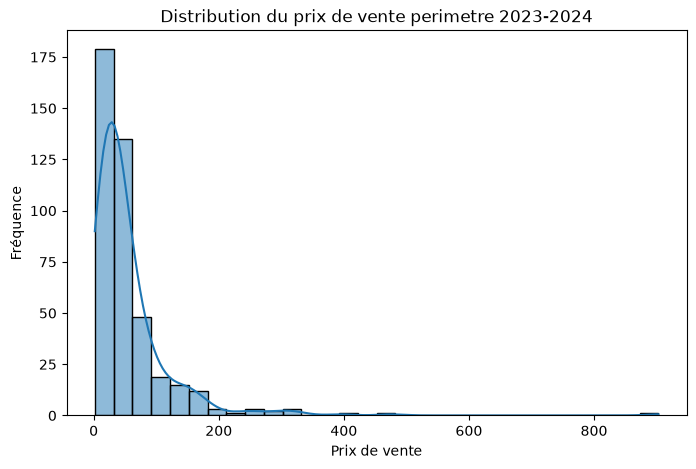

In [38]:
# Nous constatons que La variable prix de vente présente une forte dispersion (écart-type = 71,57), supérieure à sa moyenne (55,43), ce qui traduit une grande variabilité des montants de vente. La moyenne étant nettement supérieure à la médiane (36,29), la distribution semble asymétrique à droite, probablement sous l'effet de quelques ventes très élevées. En effet, 75 % des ventes sont inférieures à 62,50 alors que le maximum atteint 903, ce qui suggère la présence de valeurs aberrantes. Cette asymétrie sera vérifiée à l'aide d'un histogramme, tandis que la présence de valeurs aberrantes sera confirmée par un boxplot.
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(data=ventes_completed_2023_2024,x="sale_price",bins=30,kde=True)
plt.title("Distribution du prix de vente perimetre 2023-2024")
plt.xlabel("Prix de vente")
plt.ylabel("Fréquence")

In [39]:
# L'histogramme en haut montre que la distribution des prix de vente est fortement asymétrique à droite. La majorité des ventes est concentrée sur de faibles montants, tandis qu'un petit nombre de ventes beaucoup plus élevées forme une longue queue vers la droite. Cette observation est cohérente avec le fait que la moyenne (55,43) soit supérieure à la médiane (36,29). La présence de quelques valeurs très élevées explique également la forte dispersion observée (écart-type = 71,57). La présence éventuelle de valeurs aberrantes sera confirmée à l'aide d'un boxplot.

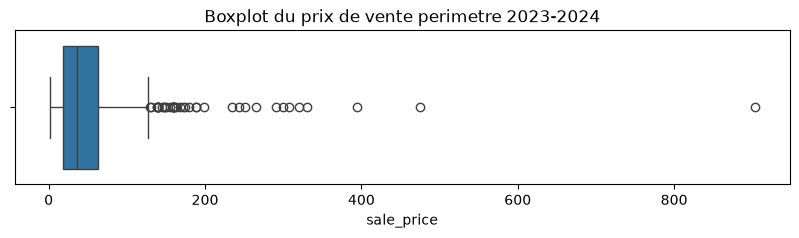

In [40]:
plt.figure(figsize=(10,2))

sns.boxplot(
    data=ventes_completed_2023_2024,
    x="sale_price"
)

plt.title("Boxplot du prix de vente perimetre 2023-2024")
plt.show()

In [41]:
# Le boxplot en haut montre que la moitié des prix de vente se situe entre le premier et le troisième quartile, tandis que de nombreuses observations apparaissent au-delà de la moustache supérieure. Ces valeurs correspondent à des valeurs aberrantes, exclusivement situées du côté des montants élevés. Cette configuration confirme une asymétrie à droite de la distribution et explique que la moyenne soit supérieure à la médiane ainsi que la forte dispersion observée.

les montants vendus par mois perimetre 2023-2024: 
 delivered_at
1     1321.31
2     1031.02
3     1407.89
4     1349.84
5     1924.10
6     2036.62
7     1206.75
8     1994.30
9     3033.81
10    3656.92
11    1720.62
12    2765.42
Name: sale_price, dtype: float64


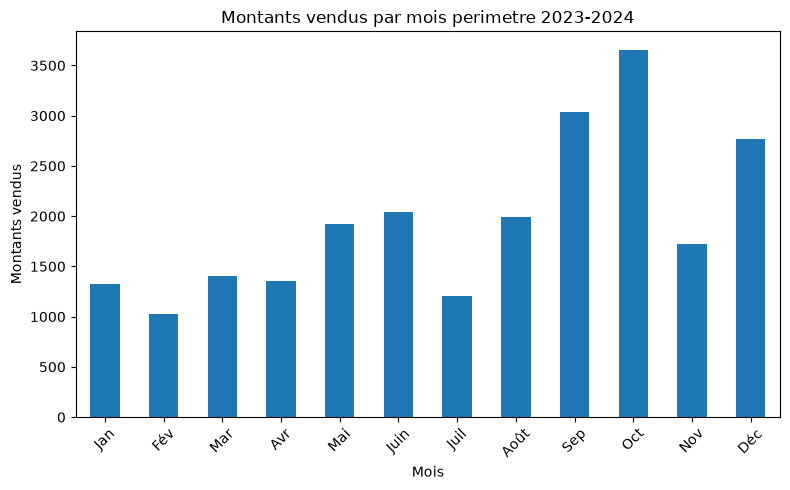

In [42]:
# Examinons la contribution mensuelle sur les ventes:
ventes_par_mois_2023_2024=ventes_completed_2023_2024.groupby(ventes_completed_2023_2024["delivered_at"].dt.month)["sale_price"].sum()
print(f"les montants vendus par mois perimetre 2023-2024: \n {ventes_par_mois_2023_2024}")
plt.figure(figsize=(8,5))
ventes_par_mois_2023_2024.plot(kind="bar")
plt.title("Montants vendus par mois perimetre 2023-2024")
plt.xlabel("Mois")
plt.ylabel("Montants vendus")
plt.xticks(
    ticks=range(12),
    labels=[
        "Jan", "Fév", "Mar", "Avr", "Mai", "Juin",
        "Juil", "Août", "Sep", "Oct", "Nov", "Déc"
    ],
    rotation=45 # position des  x label
)

plt.tight_layout()



In [43]:
# Le mois d'octobre est le mois générant beaucoup plus de ventes.

In [44]:
# Coûts:
# cost représente le Coût d'achat ou de revient du produit pour l'entreprise.Nous allons considérer la colonne cost, item_status=completed, delivred_at respectant le péripètre 2023-2024; en gros le même périmètre adopté pour les ventes.
masque_couts_items_completed_2023_2024=(df_copie["item_status"]=='Complete')&(df_copie["delivered_at"].dt.year.isin([2023,2024]))
couts_items_completed_2023_2024=df_copie[masque_couts_items_completed_2023_2024] 
print(f"Les couts dans le perimètre 2023-2024:\n{couts_items_completed_2023_2024["cost"]}")
print(f"Examinons la distribution des couts de tout le perimètre 2023-2024:\n{couts_items_completed_2023_2024["cost"].describe()}")

Les couts dans le perimètre 2023-2024:
2       18.47
3       16.40
4       29.58
6       26.04
12      17.90
        ...  
1652    12.37
1654    24.70
1656    24.86
1657    27.79
1664    15.13
Name: cost, Length: 423, dtype: float64
Examinons la distribution des couts de tout le perimètre 2023-2024:
count    423.000000
mean      26.660993
std       33.773891
min        0.750000
25%        8.730000
50%       17.970000
75%       29.695000
max      437.050000
Name: cost, dtype: float64


Text(0, 0.5, 'Fréquence')

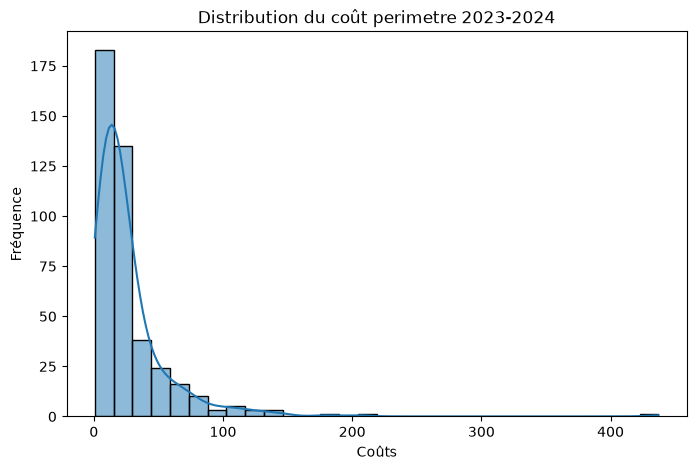

In [45]:
# Nous constatons que La variable cout présente une forte dispersion (écart-type = 33,77), supérieure à sa moyenne (26,66), ce qui traduit une grande variabilité des coûts de produits. La moyenne étant nettement supérieure à la médiane (17,97), la distribution semble asymétrique à droite, probablement sous l'effet de quelques coûts très élevées. En effet, 75 % des coûts sont inférieures à 29,69 alors que le maximum atteint 437,05, ce qui suggère la présence de valeurs aberrantes. Cette asymétrie sera vérifiée à l'aide d'un histogramme, tandis que la présence de valeurs aberrantes sera confirmée par un boxplot.
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(data=couts_items_completed_2023_2024,x="cost",bins=30,kde=True)
plt.title("Distribution du coût perimetre 2023-2024")
plt.xlabel("Coûts")
plt.ylabel("Fréquence")

In [46]:
# L'histogramme en haut montre que la distribution des coûts est fortement asymétrique à droite. La majorité des coûts est concentrée sur de faibles montants, tandis qu'un petit nombre de coûts beaucoup plus élevés forme une longue queue vers la droite. Cette observation est cohérente avec le fait que la moyenne (26,66) soit supérieure à la médiane (17,97). La présence de quelques valeurs très élevées explique également la forte dispersion observée (écart-type = 33,77 > moyenne = 26,66 ). La présence éventuelle de valeurs aberrantes sera confirmée à l'aide d'un boxplot

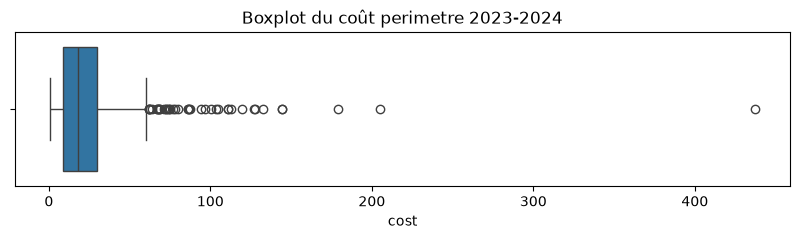

In [47]:
plt.figure(figsize=(10,2))

sns.boxplot(
    data=couts_items_completed_2023_2024,
    x="cost"
)

plt.title("Boxplot du coût perimetre 2023-2024")
plt.show()

In [48]:
# Le boxplot en haut met en évidence une distribution fortement asymétrique à droite. La moitié des coûts est comprise entre Q1 et Q3, tandis que de nombreuses valeurs aberrantes apparaissent au-delà de la moustache supérieure. Ces coûts exceptionnellement élevés étirent la distribution vers la droite, ce qui contribue à une moyenne supérieure à la médiane et à une dispersion importante des coûts

les montants dépensés par mois perimetre 2023-2024: 
 delivered_at
1      670.76
2      491.82
3      675.00
4      627.81
5      896.30
6      949.55
7      580.22
8      993.67
9     1492.45
10    1709.36
11     866.57
12    1324.09
Name: cost, dtype: float64


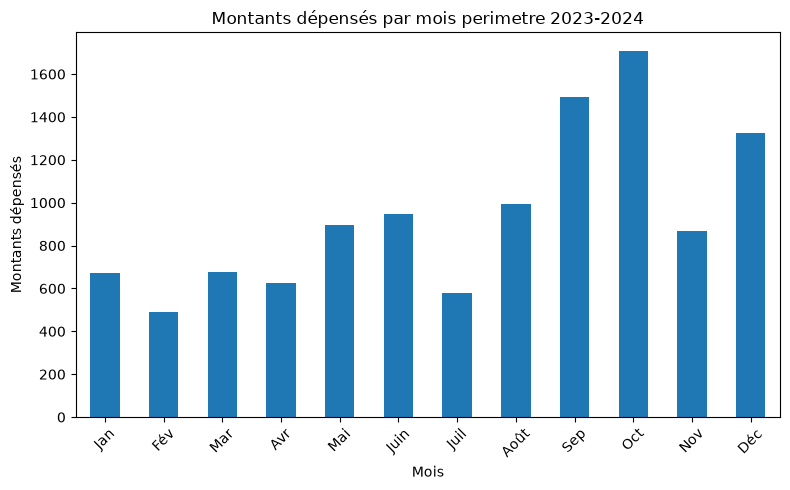

In [49]:
# Examinons les coûts/dépenses  mensuelles:
couts_par_mois_2023_2024=couts_items_completed_2023_2024.groupby(couts_items_completed_2023_2024["delivered_at"].dt.month)["cost"].sum()
print(f"les montants dépensés par mois perimetre 2023-2024: \n {couts_par_mois_2023_2024}")
plt.figure(figsize=(8,5))
couts_par_mois_2023_2024.plot(kind="bar")
plt.title("Montants dépensés par mois perimetre 2023-2024")
plt.xlabel("Mois")
plt.ylabel("Montants dépensés")
plt.xticks(
    ticks=range(12),
    labels=[
        "Jan", "Fév", "Mar", "Avr", "Mai", "Juin",
        "Juil", "Août", "Sep", "Oct", "Nov", "Déc"
    ],
    rotation=45 # position des  x label
)

plt.tight_layout()

In [50]:
# Les dépenses/investissements sont plus important au mois d'octobre.
# Les coûts ont l'air de suivre la même tendance que les ventes. Pour confirmer celà, nous allons placer dans un même graphe: ventes, coûts et aussi marge_par_mois_2023_2024s.

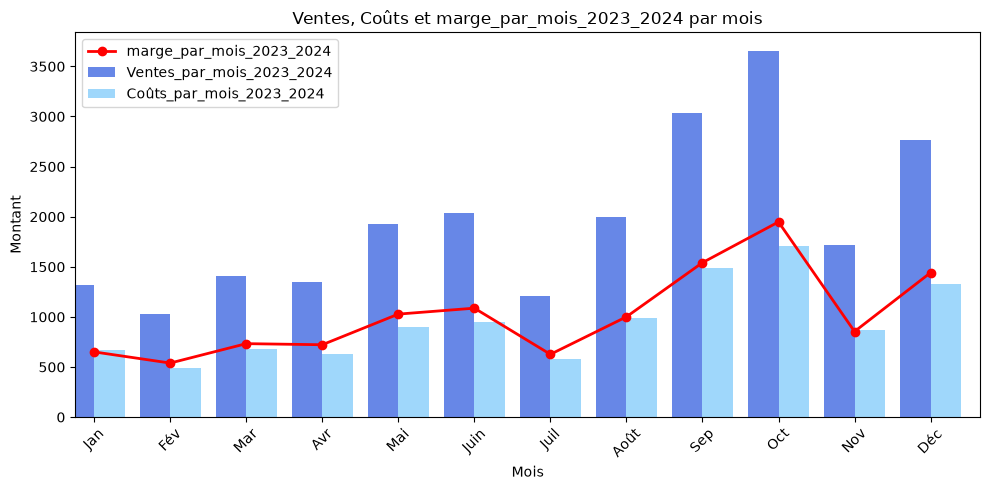

In [51]:
import numpy as np
# Calcul de la marge_par_mois_2023_2024
marge_par_mois_2023_2024 = ventes_par_mois_2023_2024 - couts_par_mois_2023_2024

x = np.arange(len(marge_par_mois_2023_2024))

fig, ax = plt.subplots(figsize=(10, 5))

# Barres
ventes_par_mois_2023_2024.plot(
    kind="bar",
    ax=ax,
    color="royalblue",
    alpha=0.8,
    width=0.4,
    position=1,
    label="Ventes_par_mois_2023_2024"
)

couts_par_mois_2023_2024.plot(
    kind="bar",
    ax=ax,
    color="lightskyblue",
    alpha=0.8,
    width=0.4,
    position=0,
    label="Coûts_par_mois_2023_2024"
)

# Ligne de marge_par_mois_2023_2024
#marge_par_mois_2023_2024.plot(
 #   ax=ax,
  #  color="red",
   # marker="o",
    #linewidth=2,
    #label="marge_par_mois_2023_2024"
#)
ax.plot(
    x,
    marge_par_mois_2023_2024.values,
    color="red",
    marker="o",
    linewidth=2,
    label="marge_par_mois_2023_2024"
)

ax.set_title("Ventes, Coûts et marge_par_mois_2023_2024 par mois")
ax.set_xlabel("Mois")
ax.set_ylabel("Montant")
ax.legend()
plt.xticks(
    ticks=range(12),
    labels=[
        "Jan", "Fév", "Mar", "Avr", "Mai", "Juin",
        "Juil", "Août", "Sep", "Oct", "Nov", "Déc"
    ],
    rotation=45 # position des  x label
)

plt.tight_layout()

In [52]:
# Le graphique met en évidence une évolution conjointe des ventes, des coûts et de la marge_par_mois_2023_2024 sur les données cumulées des années 2023 et 2024.

# Les ventes sont supérieures aux coûts pour chacun des mois, ce qui se traduit par une marge_par_mois_2023_2024 positive sur toute la période. Cela indique que les ventes couvrent systématiquement les coûts enregistrés.

# On observe une progression globale des ventes au cours de l'année, avec une accélération à partir du mois de septembre. Les ventes atteignent leur maximum en octobre, avant de diminuer en novembre puis de repartir à la hausse en décembre. Cette évolution peut traduire un effet saisonnier ou une augmentation de l'activité en fin d'année.

# Les coûts suivent une tendance similaire à celle des ventes. Ils augmentent lorsque le volume des ventes augmente, ce qui suggère une relation cohérente entre le coût des produits vendus et le chiffre d'affaires.

# La marge_par_mois_2023_2024 évolue également de manière positive. Elle reste relativement stable durant le premier semestre (entre environ 540 € et 1 090 €), puis augmente sensiblement à partir de septembre pour atteindre son niveau le plus élevé en octobre (près de 1 950 €). Cette hausse indique que l'augmentation des ventes est plus importante que celle des coûts sur cette période.

# Dans l'ensemble, les derniers mois de l'année (septembre à décembre) apparaissent comme les plus performants, notamment octobre, qui constitue le meilleur mois en termes de chiffre d'affaires et de marge_par_mois_2023_2024. 
# Dans cet intervalle septembre-decembre, nous notons quand même un creux au mois de novembre. Peut être le nombre de ventes diminue en Novembre ? ou les articles vendus au mois de novembre ont ils des prix bas ?
# Confirmons celà en regardant les volumes de ventes et les prix moyens des articles en cette période (septembre à décembre). 

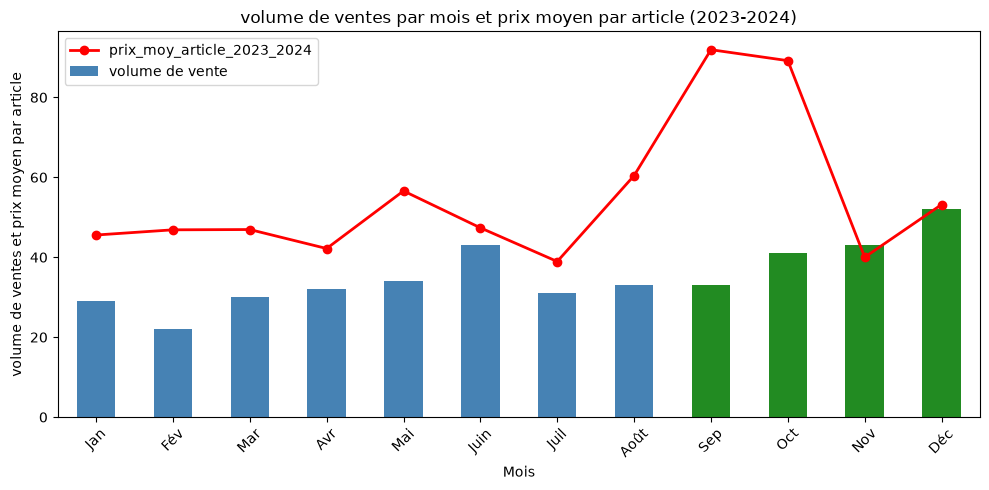

In [60]:
# Regardons les volumes de ventes et les prix moyens des articles.
x=np.arange(0,12)
months=np.arange(1,13)
prix_moy_article: list[float]=[]
for i in months:
    prix_moy_article.append(ventes_completed_2023_2024[ventes_completed_2023_2024["delivered_at"].dt.month==i]["sale_price"].mean().round(2))
prix_moy_article_2023_2024=pd.Series(prix_moy_article)



# Volume de ventes
volumes_ventes_par_mois_2023_2024 = ventes_completed_2023_2024.groupby(
    ventes_completed_2023_2024["delivered_at"].dt.month
).size()

# Couleurs des barres
couleurs = ["steelblue"] * 8 + ["forestgreen"] * 4

fig,axi=plt.subplots(figsize=(10, 5))

volumes_ventes_par_mois_2023_2024.plot(
    kind="bar",
    color=couleurs,
    label="volume de vente",
    ax=axi
)

axi.plot(
    x,
    prix_moy_article_2023_2024.values,
    color="red",
    marker="o",
    linewidth=2,
    label="prix_moy_article_2023_2024"
)

plt.title("volume de ventes par mois et prix moyen par article (2023-2024)")
plt.xlabel("Mois")
plt.ylabel("volume de ventes et prix moyen par article")
axi.legend()
plt.xticks(
    ticks=range(12),
    labels=[
        "Jan", "Fév", "Mar", "Avr", "Mai", "Juin",
        "Juil", "Août", "Sep", "Oct", "Nov", "Déc"
    ],
    rotation=45
)

plt.tight_layout()

In [54]:
# Le graphique « Ventes, Coûts et Marge par mois (2023-2024) » a montré que le chiffre d'affaires diminue fortement entre octobre et novembre, passant d'environ 3 650 à 1 700, soit une baisse de plus de 50 %. En s'appuyant sur le graphique « Volume de ventes par mois et prix moyen par article (2023-2024) » que nous venons de construire, on constate que cette baisse s'explique principalement par une forte diminution du prix moyen par article, qui passe d'environ 89 à 40 (soit également une baisse de plus de 50 %).

les contributions des 15 marques les plus pertinentes:
brand
The North Face               1211.00
PAIGE                         800.97
Arc'teryx                     620.00
Jones New York                516.99
Ray-Ban                       479.90
Not Your Daughter's Jeans     418.00
Rebecca Taylor                395.00
McGinn                        330.00
Natori                        320.00
BGSD                          319.99
Allegra K                     310.76
Calvin Klein                  292.00
Trina Turk                    290.28
Roxy                          287.34
SmartWool                     272.69
Name: sale_price, dtype: float64
Leur représentation:



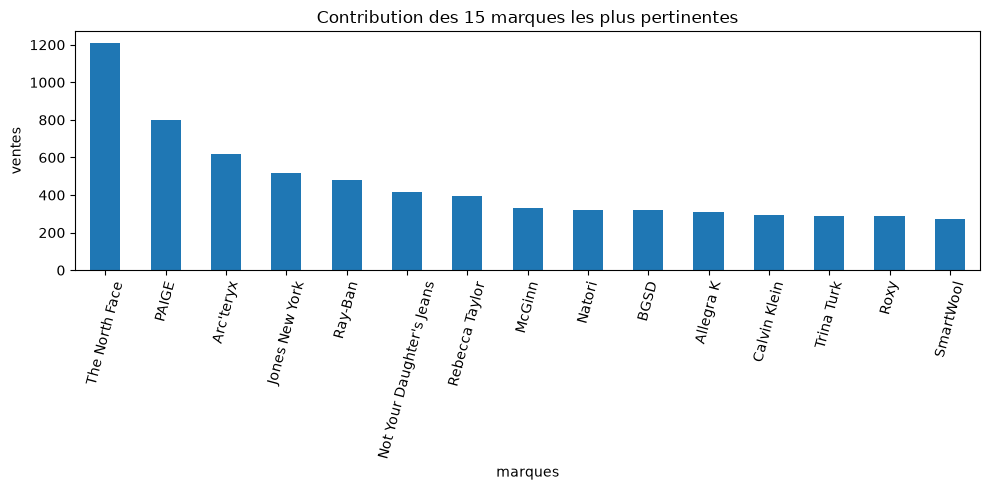

In [55]:
# Examinons la contribution des 15 marques les plus pertinentes sur les ventes.
contribution_par_marque=ventes_completed_2023_2024.groupby("brand")["sale_price"].sum().sort_values(ascending=False).head(15)
print(f"les contributions des 15 marques les plus pertinentes:\n{contribution_par_marque}")
print("Leur représentation:\n")
plt.figure(figsize=(10,5))
contribution_par_marque.plot(kind="bar")
plt.xlabel("marques")
plt.ylabel("ventes")
plt.title("Contribution des 15 marques les plus pertinentes")
plt.xticks(
    ticks=range(15),
    labels=contribution_par_marque.index,
    rotation=75

)
plt.tight_layout()


les contributions des 15 categories les plus pertinentes:
category
Outerwear & Coats                3147.65
Intimates                        2259.31
Jeans                            2023.56
Sweaters                         1827.21
Fashion Hoodies & Sweatshirts    1785.07
Dresses                          1340.65
Sleep & Lounge                   1257.84
Swim                             1227.04
Pants & Capris                   1225.92
Accessories                      1046.94
Maternity                         965.59
Active                            961.25
Shorts                            841.53
Blazers & Jackets                 830.77
Plus                              728.05
Name: sale_price, dtype: float64
Leur représentation:



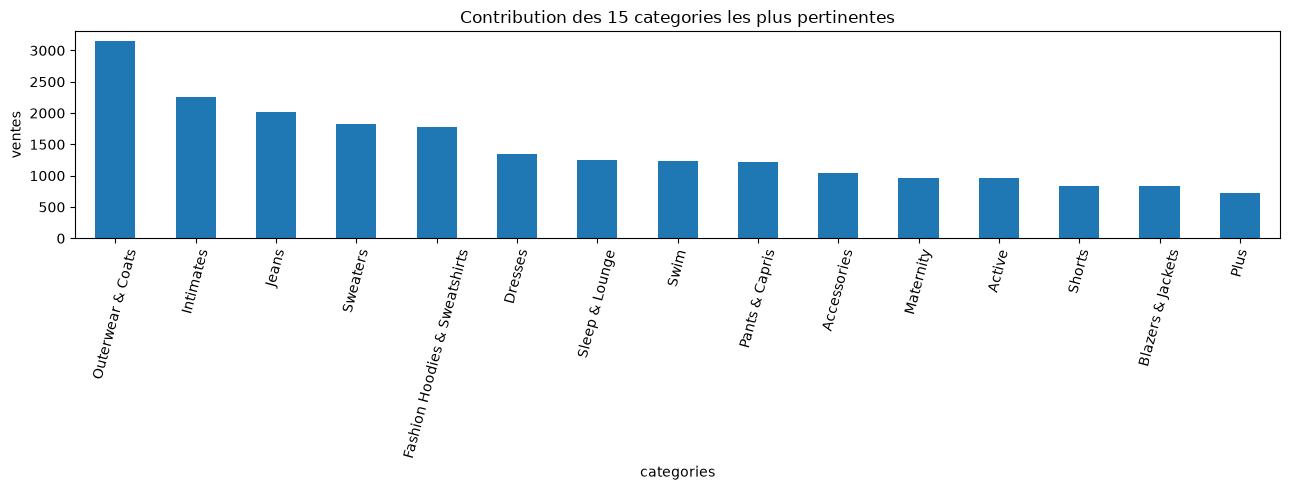

In [56]:
# Examinons la contribution des 15 catégories les plus pertinentes sur les ventes.
contribution_par_categorie=ventes_completed_2023_2024.groupby("category")["sale_price"].sum().sort_values(ascending=False).head(15)
print(f"les contributions des 15 categories les plus pertinentes:\n{contribution_par_categorie}")
print("Leur représentation:\n")
plt.figure(figsize=(13,5))
contribution_par_categorie.plot(kind="bar")
plt.xlabel("categories")
plt.ylabel("ventes")
plt.title("Contribution des 15 categories les plus pertinentes")
plt.xticks(
    ticks=range(15),
    labels=contribution_par_categorie.index,
    rotation=75

)
plt.tight_layout()

les contributions des 15 villes les plus pertinentes:
city
Paris                  949.83
Locon                  903.00
Vandœuvre-lès-Nancy    822.96
Lyon                   536.44
Brignoles              509.90
Malakoff               436.53
Nice                   435.40
Aubagne                431.89
Saint-Chamond          396.42
Hasparren              363.92
Saint-Mandé            330.00
Évry-Courcouronnes     315.28
Villethierry           311.50
Grenoble               309.14
Laplume                308.00
Name: sale_price, dtype: float64
Leur représentation:



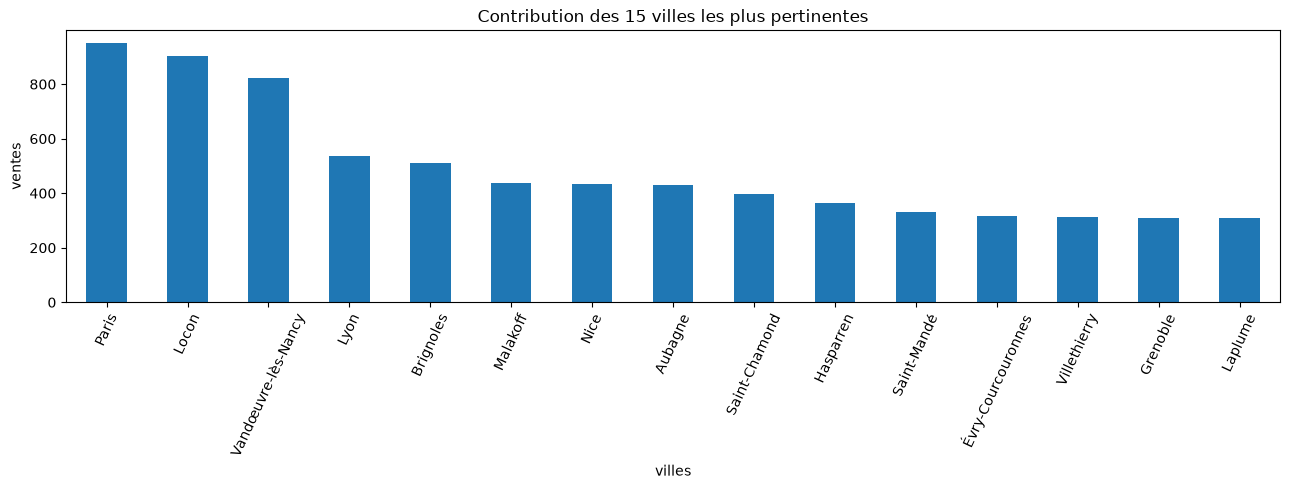

In [57]:
# Examinons la contribution des 15 villes les plus pertinentes sur les ventes.
contribution_par_ville=ventes_completed_2023_2024.groupby("city")["sale_price"].sum().sort_values(ascending=False).head(15)
print(f"les contributions des 15 villes les plus pertinentes:\n{contribution_par_ville}")
print("Leur représentation:\n")
plt.figure(figsize=(13,5))
contribution_par_ville.plot(kind="bar")
plt.xlabel("villes")
plt.ylabel("ventes")
plt.title("Contribution des 15 villes les plus pertinentes")
plt.xticks(
    ticks=range(15),
    labels=contribution_par_ville.index,
    rotation=65

)
plt.tight_layout()

**********************COMPARAISON 2023 vs 2024**************************


In [58]:
# Chiffre d'affaires 2023 
masque_chiffre_affaires_2023=(df_copie["item_status"]=='Complete')&(df_copie["delivered_at"].dt.year==2023)
chiffre_affaires_2023=df_copie[masque_chiffre_affaires_2023]["sale_price"].sum()
# Cost 2023
cost_2023=df_copie[masque_chiffre_affaires_2023]["cost"].sum()
# Marge Brute 2023 
marge_brute_2023=chiffre_affaires_2023-cost_2023
# Nombre de commandes 2023 avec revenu > 0, item_status utilisé depuis le chiffre d'affaires
masque_commandes_2023_rev_positif=(df_copie["item_status"]=='Complete')&(df_copie["delivered_at"].dt.year==2023)
nombre_commandes_rev_positif_2023=df_copie[masque_commandes_2023_rev_positif]["order_id"].nunique()
# Panier moyen 2023
panier_moyen_2023=chiffre_affaires_2023/nombre_commandes_rev_positif_2023
# Taux de retour 2023
masque_retour_2023=(df_copie["item_status"]=='Returned')&(df_copie["delivered_at"].dt.year==2023)
retour_2023=len(df_copie[masque_retour_2023])
ventes_2023=len(df_copie[masque_chiffre_affaires_2023])
vendues_2023=retour_2023+ventes_2023
taux_retour_2023=(retour_2023/vendues_2023)*100

# Commandes complètes de 2023
commandes_completes_2023 = df_copie[
    (df_copie["item_status"] == "Complete") &  # C'est item_status utilisé depuis le chiffre d'affaire
    (df_copie["delivered_at"].dt.year == 2023)
]
# Nombre total de clients ayant au moins une commande complète
nombre_clients_2023 = commandes_completes_2023["user_id"].nunique()
# Nombre de commandes complètes par client
nb_commandes_par_client_2023 = (
    commandes_completes_2023
    .groupby("user_id")["order_id"]
    .nunique()
)
# Clients ayant effectué au moins 2 commandes complètes
clients_reachat_2023 = (nb_commandes_par_client_2023 >= 2).sum()
# Taux de ré-achat 2023
taux_reachat_2023 = (clients_reachat_2023 / nombre_clients_2023) * 100

# valeurs kpi 2023
kpi_2023:np.ndarray=np.array([chiffre_affaires_2023,marge_brute_2023,nombre_commandes_rev_positif_2023,panier_moyen_2023,taux_retour_2023,taux_reachat_2023])

# Chiffre d'affaires 2024 
masque_chiffre_affaires_2024=(df_copie["item_status"]=='Complete')&(df_copie["delivered_at"].dt.year==2024)
chiffre_affaires_2024=df_copie[masque_chiffre_affaires_2024]["sale_price"].sum()
# Cost 2024
cost_2024=df_copie[masque_chiffre_affaires_2024]["cost"].sum()
# Marge Brute 2024 
marge_brute_2024=chiffre_affaires_2024-cost_2024
# Nombre de commandes 2024 avec revenu > 0
masque_commandes_2024_rev_positif=(df_copie["item_status"]=='Complete')&(df_copie["delivered_at"].dt.year==2024)
nombre_commandes_rev_positif_2024=df_copie[masque_commandes_2024_rev_positif]["order_id"].nunique()
# Panier moyen 2024
panier_moyen_2024=chiffre_affaires_2024/nombre_commandes_rev_positif_2024
# Taux de retour 2024
masque_retour_2024=(df_copie["item_status"]=='Returned')&(df_copie["delivered_at"].dt.year==2024)
retour_2024=len(df_copie[masque_retour_2024])
ventes_2024=len(df_copie[masque_chiffre_affaires_2024])
vendues_2024=retour_2024+ventes_2024
taux_retour_2024=(retour_2024/vendues_2024)*100
# Commandes complètes de 2024
commandes_completes_2024 = df_copie[
    (df_copie["item_status"] == "Complete") &
    (df_copie["delivered_at"].dt.year == 2024)
]
# Nombre total de clients ayant au moins une commande complète
nombre_clients_2024 = commandes_completes_2024["user_id"].nunique()
# Nombre de commandes complètes par client
nb_commandes_par_client_2024 = (
    commandes_completes_2024
    .groupby("user_id")["order_id"]
    .nunique()
)
# Clients ayant effectué au moins 2 commandes complètes
clients_reachat_2024 = (nb_commandes_par_client_2024 >= 2).sum()
# Taux de ré-achat
taux_reachat_2024 =(clients_reachat_2024 / nombre_clients_2024)* 100

# valeurs kpi 2024
kpi_2024:np.ndarray=np.array([chiffre_affaires_2024,marge_brute_2024,nombre_commandes_rev_positif_2024,panier_moyen_2024,taux_retour_2024,taux_reachat_2024])

# Ecart absolu 
ecart_absolu:np.ndarray=kpi_2024-kpi_2023
# Ecart relatif
ecart_relatif:np.ndarray=(kpi_2024-kpi_2023)*100/kpi_2023

# Comparaison KPIs 2023 vs 2024
df_kpi_2023_2024=pd.DataFrame({
    "Noms KPIs":["Chiffre d'affaires","Marge brute","Nombre de commandes à revenu positif","Panier moyen","Taux de retour","Taux de ré-achat"],
    2023:kpi_2023,
    2024:kpi_2024,
    "ecart absolu":ecart_absolu,
    "ecart relatif":ecart_relatif
})

df_kpi_2023_2024.round(2) # affichage comparatif des KPIs 2023 vs 2024



C:\Users\user\AppData\Local\Temp\ipykernel_15080\3747085563.py:83: RuntimeWarning: divide by zero encountered in divide
  ecart_relatif:np.ndarray=(kpi_2024-kpi_2023)*100/kpi_2023


,Noms KPIs,2023,2024,ecart absolu,ecart relatif
0,Chiffre d'affaires,7781.33,15667.27,7885.94,101.34
1,Marge brute,4063.45,8107.55,4044.10,99.52
2,Nombre de commandes à revenu positif,96.00,183.00,87.00,90.62
3,Panier moyen,81.06,85.61,4.56,5.62
4,Taux de retour,38.03,30.50,-7.53,-19.81
5,Taux de ré-achat,0.00,3.41,3.41,inf


A la lecture du tableau comparatif des années 2023 et 2024, nous pouvons voir que les performances commerciales s'améliorent nettement sur la plupart des indicateurs:
-Le chiffre d'affaires passe de 7 781,33 à 15 667,27; soit une hausse de 7 885,94 (+101,34 %). Le chiffre d'affaires a donc plus que doublé en un an.
-La marge brute évolue de 4 063,52 à 8 107,51, soit une augmentation de 4 043,98 (+99,52 %). La marge progresse presque au même rythme que le chiffre d'affaires, ce qui indique que la rentabilité brute est restée globalement stable malgré la forte croissance des ventes.
-Le nombre de commandes augmente de 96 à 183, soit 87 commandes supplémentaires (+90,62 %). Cette progression explique en grande partie la hausse du chiffre d'affaires.
-Le panier moyen progresse légèrement, passant de 81,06 à 85,61 (+5,62 %). Les clients dépensent donc un peu plus par commande en 2024, mais cette augmentation reste modérée. La croissance du chiffre d'affaires provient donc principalement de l'augmentation du nombre de commandes plutôt que d'une forte hausse du panier moyen
-Le taux de retour diminue de 38,03 % à 30,50 %, soit une baisse de 7,53 points (−19,81 %). Cette évolution est favorable, car elle traduit une diminution de la proportion d'articles retournés.
-Le taux de ré-achat passe de 0 % en 2023 à 3,41 % en 2024, ce qui traduit l'apparition de clients fidèles en 2024. L'écart relatif n'est pas calculable car la valeur de référence en 2023 est nulle.

L'analyse met en évidence une forte amélioration de la performance commerciale en 2024. Le chiffre d'affaires et la marge brute ont presque doublé, principalement grâce à une hausse importante du nombre de commandes (+90,62 %). Le panier moyen progresse légèrement, tandis que le taux de retour diminue de près de 20 %, ce qui traduit une amélioration de la qualité des ventes. Enfin, l'apparition d'un taux de ré-achat positif (3,41 %) suggère un début de fidélisation de la clientèle en 2024.

Le taux de retour diminue de 38,03 % à 30,50 %, ce qui traduit une amélioration de la qualité des ventes. Les principales causes et caractéristiques des retours et des annulations ont déjà été analysées dans la section consacrée à l'analyse exploratoire du périmètre 2023–2024.

Ajoutons des series mensuelles

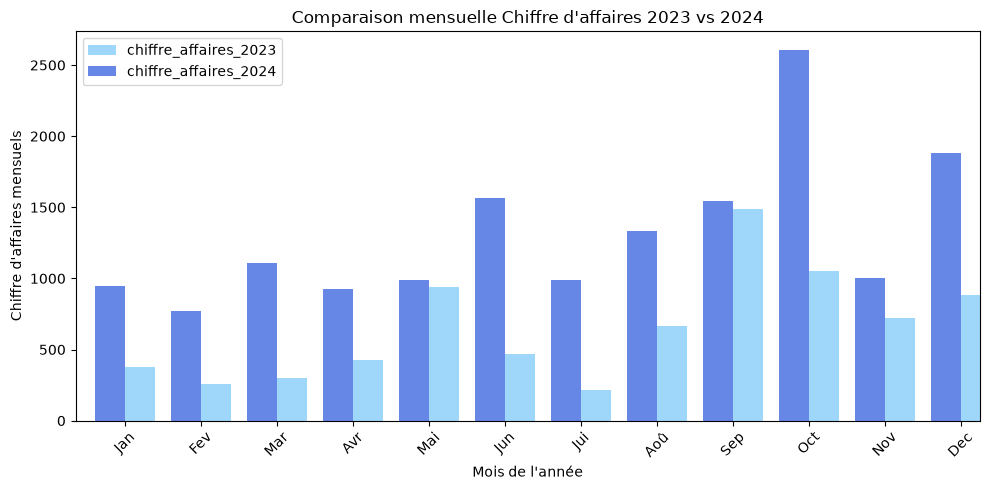

In [64]:
# Chiffre d'affaires mensuel 2023
masque_chiffre_affaires_2023=(df_copie["item_status"]=='Complete')&(df_copie["delivered_at"].dt.year==2023)
chiffre_affaires_2023_mensuel=df_copie[masque_chiffre_affaires_2023].groupby(df_copie[masque_chiffre_affaires_2023]["delivered_at"].dt.month)["sale_price"].sum()
# Chiffre d'affaires mensuel 2024
masque_chiffre_affaires_2024=(df_copie["item_status"]=='Complete')&(df_copie["delivered_at"].dt.year==2024)
chiffre_affaires_2024_mensuel=df_copie[masque_chiffre_affaires_2024].groupby(df_copie[masque_chiffre_affaires_2024]["delivered_at"].dt.month)["sale_price"].sum()
# Représentation mensuelle des chiffres d'affaires 2023 et 2024
fig,axi=plt.subplots(figsize=(10,5))
chiffre_affaires_2023_mensuel.plot(
    kind="bar",
    ax=axi,
    color="lightskyblue",
    alpha=0.8,
    width=0.4,
    position=0,
    label="chiffre_affaires_2023"
)
chiffre_affaires_2024_mensuel.plot(
    kind="bar",
    ax=axi,
    color="royalblue",
    alpha=0.8,
    width=0.4,
    position=1,
    label="chiffre_affaires_2024"
)
axi.set_title("Comparaison mensuelle Chiffre d'affaires 2023 vs 2024")
axi.set_xlabel("Mois de l'année")
axi.set_ylabel("Chiffre d'affaires mensuels")
axi.legend()
plt.xticks(
    ticks=range(12),
    labels=["Jan","Fev","Mar","Avr","Mai","Jun","Jui","Aoû","Sep","Oct","Nov","Dec"],
    rotation=45
)
plt.tight_layout()

*******Analyse par mois*******
-Janvier à avril : le chiffre d'affaires de 2024 est environ de deux à trois fois supérieur à celui de 2023. Le début de l'année est donc nettement meilleur.
-Mai : les deux années sont très proches. C'est le mois où la progression est la plus faible.
-Juin : forte reprise en 2024 avec un chiffre d'affaires dépassant largement celui de 2023.
-Juillet et août : la progression reste importante, ce qui indique que l'activité estivale a été beaucoup plus dynamique en 2024.
-Septembre : les deux années sont relativement proches, même si 2024 reste légèrement supérieure.
-Octobre : c'est le mois qui présente la plus forte différence. Le chiffre d'affaires passe d'environ 1 050 en 2023 à près de 2 600 en 2024, soit une hausse d'environ 150 %.
-Novembre et décembre : la fin de l'année 2024 reste très performante, notamment en décembre où le chiffre d'affaires est environ deux fois supérieur à celui de 2023.

*******Saisonnalité*******
On observe également une évolution différente selon les années :
-En 2023, le chiffre d'affaires atteint son maximum en septembre, puis diminue en octobre et novembre, pour clôturer l'année avec un léger rebond en décembre..
-En 2024, la croissance se poursuit jusqu'en octobre, qui constitue le meilleur mois de l'année, avant une légère baisse en novembre puis un rebond en décembre.

Cette différence entre 2023 et 2024 peut traduire :

-une meilleure stratégie commerciale  ;
-des campagnes promotionnelles plus efficaces ;
-un volume de commandes plus élevé ;
-ou encore une augmentation du panier moyen.

Remarque : La baisse du chiffre d'affaires observée au mois de novembre, aussi bien en 2023 qu'en 2024, a déjà été analysée dans la section Analyse exploratoire. Cette diminution s'explique principalement par une baisse du prix moyen des articles vendus au cours de ce mois.

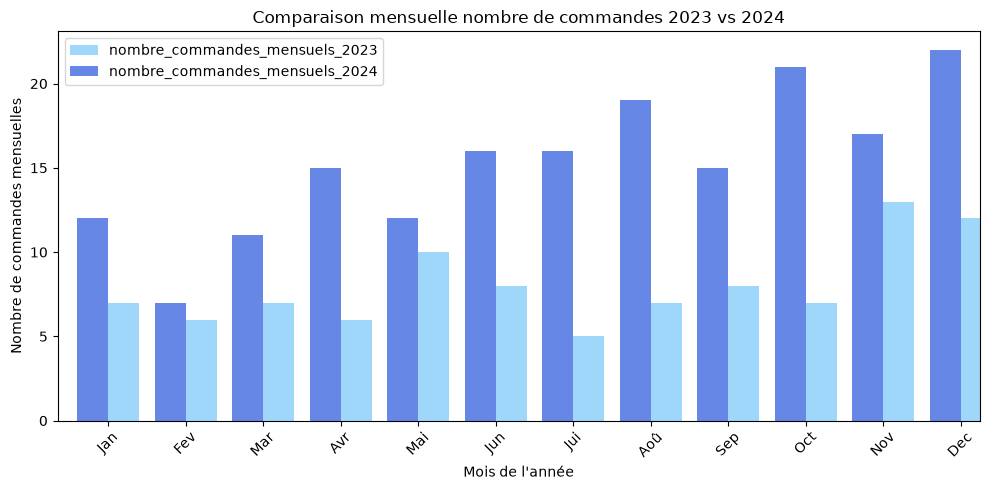

In [73]:
# Comparaison des nombres de commandes mensuelles 2023 vs 2024
nombre_commandes_mensuels_2023=df_copie[masque_commandes_2023_rev_positif].groupby(df_copie[masque_commandes_2023_rev_positif]["delivered_at"].dt.month)["order_id"].nunique()
nombre_commandes_mensuels_2024=df_copie[masque_commandes_2024_rev_positif].groupby(df_copie[masque_commandes_2024_rev_positif]["delivered_at"].dt.month)["order_id"].nunique()
fig,axi=plt.subplots(figsize=(10,5))
nombre_commandes_mensuels_2023.plot(
    kind="bar",
    ax=axi,
    color="lightskyblue",
    alpha=0.8,
    width=0.4,
    position=0,
    label="nombre_commandes_mensuels_2023"
)
nombre_commandes_mensuels_2024.plot(
    kind="bar",
    ax=axi,
    color="royalblue",
    alpha=0.8,
    width=0.4,
    position=1,
    label="nombre_commandes_mensuels_2024"
)
axi.set_title("Comparaison mensuelle nombre de commandes 2023 vs 2024")
axi.set_xlabel("Mois de l'année")
axi.set_ylabel("Nombre de commandes mensuelles")
axi.legend()
plt.xticks(
    ticks=range(12),
    labels=["Jan","Fev","Mar","Avr","Mai","Jun","Jui","Aoû","Sep","Oct","Nov","Dec"],
    rotation=45
)
plt.tight_layout()


Analyse de la comparaison mensuelle du nombre de commandes (2023 vs 2024)

Le graphique met en évidence une augmentation du nombre de commandes en 2024 par rapport à 2023 pour l'ensemble des mois de l'année. Cette évolution confirme une amélioration de l'activité commerciale en 2024.

Plus précisément :

-De janvier à juin, le nombre de commandes est systématiquement supérieur en 2024, avec une progression particulièrement marquée en avril et en juin.
-De juillet à octobre, l'écart se creuse davantage. Le mois d'octobre enregistre un niveau particulièrement élevé, avec environ 21 commandes en 2024 contre 7 en 2023, soit un triplement du volume de commandes.
-Novembre et décembre confirment cette dynamique positive. Le nombre de commandes atteint son maximum en décembre 2024 (environ 22 commandes), contre environ 12 commandes en décembre 2023.

Cette hausse du nombre de commandes explique en partie l'augmentation du chiffre d'affaires observée en 2024. Toutefois, le chiffre d'affaires ne dépend pas uniquement du volume de commandes, mais également du "panier moyen". Il est donc pertinent de compléter cette analyse avec la comparaison du "panier moyen" afin de déterminer si la croissance du chiffre d'affaires provient principalement d'une augmentation du nombre de commandes, d'une hausse du montant moyen des commandes, ou de la combinaison des deux.

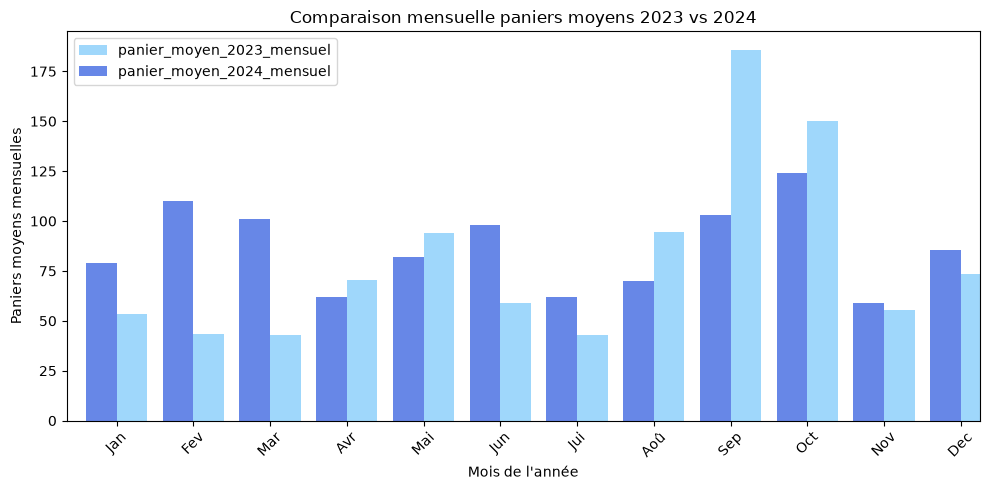

In [68]:
# Comparaison des paniers moyen mensuelles 2023 vs 2024
# Panier moyen 2023
panier_moyen_2023_mensuel=chiffre_affaires_2023_mensuel/nombre_commandes_mensuels_2023
# Panier moyen 2024
panier_moyen_2024_mensuel=chiffre_affaires_2024_mensuel/nombre_commandes_mensuels_2024
# Représentation mensuelle des marges brutes 2023 vs 2024
fig,axi=plt.subplots(figsize=(10,5))
panier_moyen_2023_mensuel.plot(
    kind="bar",
    ax=axi,
    color="lightskyblue",
    alpha=0.8,
    width=0.4,
    position=0,
    label="panier_moyen_2023_mensuel"
)
panier_moyen_2024_mensuel.plot(
    kind="bar",
    ax=axi,
    color="royalblue",
    alpha=0.8,
    width=0.4,
    position=1,
    label="panier_moyen_2024_mensuel"
)
axi.set_title("Comparaison mensuelle paniers moyens 2023 vs 2024")
axi.set_xlabel("Mois de l'année")
axi.set_ylabel("Paniers moyens mensuelles")
axi.legend()
plt.xticks(
    ticks=range(12),
    labels=["Jan","Fev","Mar","Avr","Mai","Jun","Jui","Aoû","Sep","Oct","Nov","Dec"],
    rotation=45
)
plt.tight_layout()

Analyse de la comparaison mensuelle du panier moyen (2023 vs 2024)

Le graphique montre que l'évolution du panier moyen mensuel est plus contrastée que celle du chiffre d'affaires ou du nombre de commandes. Contrairement à ces deux indicateurs, 2024 ne surpasse pas systématiquement 2023.

Plus précisément :

-De janvier à mars, le panier moyen est nettement plus élevé en 2024 qu'en 2023. Cela indique que, durant le premier trimestre, les clients ont dépensé davantage par commande.
-En avril et mai, le panier moyen est légèrement inférieur en 2024, mais l'écart reste limité.
-En juin et juillet, le panier moyen retrouve un niveau supérieur à celui de 2023.
-D'août à octobre, la tendance s'inverse : le panier moyen est significativement plus élevé en 2023. L'écart est particulièrement marqué en septembre et octobre, où 2023 atteint ses valeurs maximales.
-En novembre, les deux années présentent un panier moyen très proche.
-En décembre, 2024 retrouve un avantage avec un panier moyen supérieur à celui de 2023.

Interprétation

L'analyse conjointe avec les graphiques précédents montre que la forte progression du chiffre d'affaires en 2024 est principalement liée à l'augmentation du nombre de commandes plutôt qu'à une hausse systématique du panier moyen.

En effet, malgré un panier moyen parfois inférieur (notamment entre août et octobre), le chiffre d'affaires reste plus élevé en 2024 grâce à un volume de commandes nettement supérieur. À l'inverse, en septembre et octobre 2023, le panier moyen est plus élevé, mais le nombre de commandes est plus faible, ce qui limite le chiffre d'affaires global.

Conclusion

Le panier moyen mensuel varie davantage d'une année à l'autre que les autres indicateurs. Bien que 2024 affiche un panier moyen supérieur sur plusieurs mois, cette tendance n'est pas constante. L'amélioration du chiffre d'affaires observée en 2024 s'explique donc principalement par l'augmentation du nombre de commandes, tandis que le panier moyen joue un rôle secondaire et fluctue selon les périodes.

Cette conclusion complète l'analyse des KPI : la croissance de l'activité en 2024 repose avant tout sur une augmentation du volume de commandes, davantage que sur une hausse généralisée du montant moyen dépensé par commande.

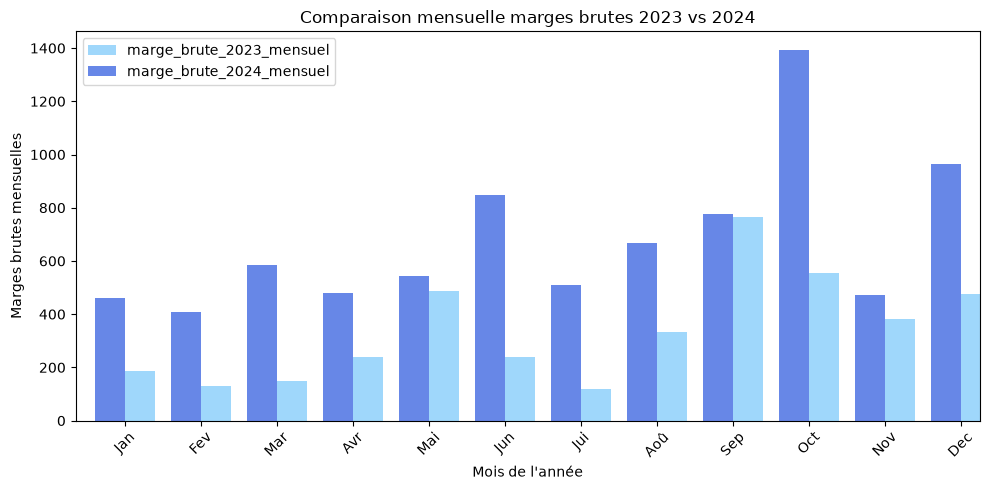

In [66]:
# Comparaison des marges brutes mensuelles 2023 vs 2024
# Cost mensuel 2023
cost_2023_mensuel=df_copie[masque_chiffre_affaires_2023].groupby(df_copie[masque_chiffre_affaires_2023]["delivered_at"].dt.month)["cost"].sum()
# Marge Brute mensuelle 2023 
marge_brute_2023_mensuel=chiffre_affaires_2023_mensuel-cost_2023_mensuel

# Cost mensuel 2024
cost_2024_mensuel=df_copie[masque_chiffre_affaires_2024].groupby(df_copie[masque_chiffre_affaires_2024]["delivered_at"].dt.month)["cost"].sum()
# Marge Brute mensuelle 2024 
marge_brute_2024_mensuel=chiffre_affaires_2024_mensuel-cost_2024_mensuel

# Représentation mensuelle des marges brutes 2023 vs 2024
fig,axi=plt.subplots(figsize=(10,5))
marge_brute_2023_mensuel.plot(
    kind="bar",
    ax=axi,
    color="lightskyblue",
    alpha=0.8,
    width=0.4,
    position=0,
    label="marge_brute_2023_mensuel"
)
marge_brute_2024_mensuel.plot(
    kind="bar",
    ax=axi,
    color="royalblue",
    alpha=0.8,
    width=0.4,
    position=1,
    label="marge_brute_2024_mensuel"
)
axi.set_title("Comparaison mensuelle marges brutes 2023 vs 2024")
axi.set_xlabel("Mois de l'année")
axi.set_ylabel("Marges brutes mensuelles")
axi.legend()
plt.xticks(
    ticks=range(12),
    labels=["Jan","Fev","Mar","Avr","Mai","Jun","Jui","Aoû","Sep","Oct","Nov","Dec"],
    rotation=45
)
plt.tight_layout()


Analyse de la comparaison mensuelle de la marge brute (2023 vs 2024)

Le graphique met en évidence une amélioration significative de la marge brute en 2024 par rapport à 2023. Pour tous les mois de l'année, la marge brute de 2024 est supérieure à celle de 2023, ce qui traduit une meilleure rentabilité des ventes.

Plus précisément :

-De janvier à avril, la marge brute de 2024 est environ deux à trois fois supérieure à celle de 2023, reflétant une forte progression de la rentabilité dès le début de l'année.
-En mai, l'écart entre les deux années est relativement faible, les marges restant proches.
-En juin, la marge brute connaît une forte hausse en 2024, avec un niveau largement supérieur à celui observé en 2023.
-De juillet à août, la progression se poursuit, confirmant une amélioration régulière de la rentabilité.
-En septembre, les deux années présentent des marges brutes proches, bien que 2024 conserve un léger avantage.
-En octobre, l'écart est particulièrement marqué : la marge brute atteint son niveau maximal en 2024, soit plus du double de celle enregistrée en 2023.
-En novembre et décembre, la marge brute reste supérieure en 2024, avec une hausse particulièrement importante en décembre.
Interprétation

L'évolution de la marge brute suit globalement celle du chiffre d'affaires. Cette progression s'explique principalement par l'augmentation du volume de ventes en 2024, sans dégradation apparente de la rentabilité. Le fait que la marge brute progresse dans les mêmes proportions que le chiffre d'affaires suggère que les coûts n'ont pas augmenté plus rapidement que les revenus.

Le mois d'octobre 2024 constitue le point fort de l'année, combinant un chiffre d'affaires élevé et une marge brute record, ce qui en fait le mois le plus rentable de la période étudiée.

Conclusion

La marge brute mensuelle est systématiquement supérieure en 2024 par rapport à 2023. Cette évolution traduit une amélioration de la rentabilité commerciale tout au long de l'année, avec un pic remarquable en octobre. Associée à la hausse du chiffre d'affaires et du nombre de commandes, cette progression confirme que les performances de 2024 sont globalement meilleures que celles de 2023, tant en termes de revenus que de rentabilité.

Remarque : Comme pour le chiffre d'affaires, la baisse observée en novembre a déjà été analysée dans la section "analyse exploratoire". Elle est principalement liée à une diminution du prix moyen des articles vendus au cours de ce mois.

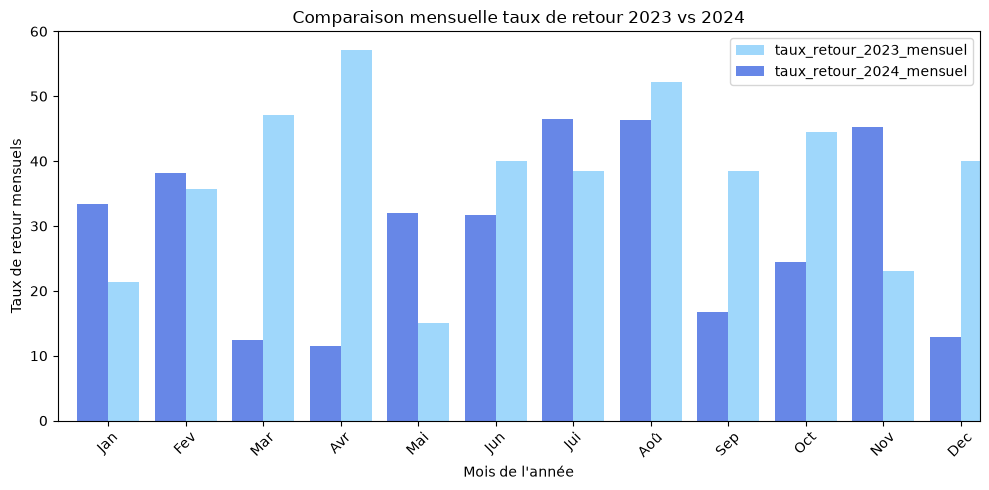

In [75]:
# Comparons les taux de retour mensuels 2023 vs 2024
# Taux de retour mensuel 2023
retour_2023_mensuel=df_copie[masque_retour_2023].groupby(df_copie[masque_retour_2023]["delivered_at"].dt.month)["order_item_id"].nunique()

ventes_2023_mensuel=df_copie[masque_chiffre_affaires_2023].groupby(df_copie[masque_chiffre_affaires_2023]["delivered_at"].dt.month)["order_item_id"].nunique()

vendues_2023_mensuel=retour_2023_mensuel+ventes_2023_mensuel

taux_retour_2023_mensuel=(retour_2023_mensuel/vendues_2023_mensuel)*100

# Taux de retour mensuel 2024
retour_2024_mensuel=df_copie[masque_retour_2024].groupby(df_copie[masque_retour_2024]["delivered_at"].dt.month)["order_item_id"].nunique()

ventes_2024_mensuel=df_copie[masque_chiffre_affaires_2024].groupby(df_copie[masque_chiffre_affaires_2024]["delivered_at"].dt.month)["order_item_id"].nunique()

vendues_2024_mensuel=retour_2024_mensuel+ventes_2024_mensuel

taux_retour_2024_mensuel=(retour_2024_mensuel/vendues_2024_mensuel)*100

# Représentation mensuelle des marges brutes 2023 vs 2024
fig,axi=plt.subplots(figsize=(10,5))
taux_retour_2023_mensuel.plot(
    kind="bar",
    ax=axi,
    color="lightskyblue",
    alpha=0.8,
    width=0.4,
    position=0,
    label="taux_retour_2023_mensuel"
)
taux_retour_2024_mensuel.plot(
    kind="bar",
    ax=axi,
    color="royalblue",
    alpha=0.8,
    width=0.4,
    position=1,
    label="taux_retour_2024_mensuel"
)
axi.set_title("Comparaison mensuelle taux de retour 2023 vs 2024")
axi.set_xlabel("Mois de l'année")
axi.set_ylabel("Taux de retour mensuels")
axi.legend()
plt.xticks(
    ticks=range(12),
    labels=["Jan","Fev","Mar","Avr","Mai","Jun","Jui","Aoû","Sep","Oct","Nov","Dec"],
    rotation=45
)
plt.tight_layout()


Ce graphique compare le taux de retour mensuel entre 2023 (barres bleu clair) et 2024 (barres bleu foncé). Plusieurs tendances se dégagent.

Analyse générale
-Le taux de retour est très variable d'un mois à l'autre pour les deux années, ce qui traduit une forte saisonnalité ou des événements ponctuels.
-Aucune des deux années ne présente systématiquement un taux de retour plus faible que l'autre : les performances alternent selon les mois.

Comparaison mois par mois:
-Janvier et février : le taux de retour est plus élevé en 2024 qu'en 2023, avec un écart particulièrement marqué en janvier.
-Mars et avril : forte amélioration en 2024. Le taux de retour chute nettement par rapport à 2023 (près de 12 % contre 47–57 %), ce qui indique une réduction importante des retours.
-Mai : tendance inverse, le taux de retour remonte en 2024 et dépasse celui de 2023.
-Juin : légère amélioration en 2024 avec un taux inférieur à celui de 2023.
-Juillet : le taux de retour est plus élevé en 2024.
-Août : les deux années présentent des taux élevés et très proches, avec un léger avantage pour 2024.
-Septembre et octobre : nette baisse du taux de retour en 2024 par rapport à 2023.
-Novembre : détérioration importante en 2024, où le taux de retour est presque deux fois supérieur à celui observé en 2023.
-Décembre : amélioration marquée en 2024 avec un taux de retour beaucoup plus faible.

Points remarquables:
-Les pics de retour en 2023 apparaissent en avril (environ 57 %) et août (environ 52 %). Ceci peut être dû au faible nombre de commande observés en ces mois; voir graphe de com
-En 2024, les valeurs les plus élevées sont observées en juillet, août et novembre (autour de 45–46 %), mais elles restent inférieures au pic d'avril 2023.

Conclusion:

Malgré quelques pics mensuels, la tendance annuelle montre une réduction globale de la proportion d'articles retournés; le taux de retour annuel passe de 38,03 % en 2023 à 30,50 % en 2024, soit une diminution de 7,53 points (-19,81 %). Voir "Comparaison mensuelle nombre de commandes 2023 vs 2024".
Cette évolution traduit une amélioration de la qualité des ventes ou de la satisfaction client. Cette performance est d'autant plus notable qu'elle s'accompagne d'une forte croissance de l'activité : le chiffre d'affaires progresse de plus de 100 %.